# Rozpoznawanie obrazu (CNN)

## Sieć konwolucyjna

Sieć konwolucyjna (CNN) to rodziaj sieci neuronowej, która w sposób zrozumiały dla maszyn próbuje odwzorować pracę ludzkiego mózgu. Dzieje się to poprzez szereg matematycznych przekształceń, kiedy to podgrupy neuronów przetwarzają równolegle różne sekcje obrazu, tworząc macierz wynikową, a docelowo wektor prawdopodobieństw. W tym wektorze każda liczba odpowiada prawdopodobieństwu jednej klasy. 

W zależności od użytej na wyjściu funkcji wszystkie liczby będą się sumować do 1, albo każda będzie w przedziale \[0,1\]. Jeśli na przykład sieć rozpoznaje, czy na obrazie jest kot, czy pies, wektor może być równy \[0.9, 0.1\] dla funkcji softmax, albo \[0.8, 0.7\] dla funkcji sigmoid. Na początku przetwarzania przez sieć konwolucyjną obraz jest tłumaczony na macierz wartości od 0 do 255 dla każdego piksela. W przypadku obrazów kolorowych muszą powstać trzy macierze dla każdego ze strumieni RGB.

![brak obrazu](images/Rys1.png)

Rysunek 1. Reprezentacja obrazu w formie macierzy liczb (źródło: https://medium.com/@ageitgey/machine-learning-is-fun-part-3-deep-learning-and-convolutional-neural-networks-f40359318721)

Podstawową funkcją sieci konwolucyjnej jest wyciąganie z obrazu jego cech. Nie odbywa się to jednak poprzez przetwarzanie całego obrazu naraz. Kluczową rolę pełnią filtry, czyli bardzo małe macierze, które są „przesuwane” po obrazie o jeden piksel. Filtr może mieć rozmiar 3x3 i jest nakładany na kolejne części macierzy obrazu o tym samym rozmiarze. Za pomocą określonej operacji matematycznej z przetwarzania tych dwóch macierzy 3x3 powstaje jedna wartość w mapie cech. Warstw z filtrami może być oczywiście wiele. 

Na Rysunku 2 widać, jak mogą powstawać wartości w mapie cech. Obraz jest uproszczony do wartości 0 i 1. Filtr (żółta macierz 3x3) jest przesuwany po obrazie (zielona macierz 5x5) i z każdego takiego przesunięcia powstaje jedna wartość w mapie cech (różowa macierz 3x3).

W tym przykładzie wartość końcowa to suma iloczynów, zatem dla danego kroku wynik powstaje w sposób następujący:

0\*1 + 0\*0 + 1\*1 + 0\*0 + 0\*1 +1\*0 + 0\*1 + 1\*0 +1\*1 = 2

![brak obrazu](images/Rys2.png)

Rysunek 2. Przykład działania filtra 3x3 na zero-jedynkowej macierzy obrazu 5x5
(źródło: https://medium.com/nybles/create-your-first-image-recognition-classifier-using-cnnkeras-
and-tensorflow-backend-6eaab98d14dd)

Wielkość mapy cech zależy od ilości warstw z filtrami oraz ich wielkości – im większy filtr, tym mniej wartości powstanie w wyniku końcowym. Filtry mogą pełnić różne funkcje, np. wyostrzanie krawędzi, wyznaczanie samych krawędzi czy rozmywanie obrazu. Wszystko zależy od procesu uczenia się sieci. Macierze filtrów są definiowane i dopasowywane w trakcie uczenia, projektant musi jedynie określić ich ilość, rozmiar i architekturę sieci.

## FASHION MNIST

Żeby odpowiedzieć na to pytanie, należy zrobić krok wstecz i wyjaśnić, czym jest MNIST. MNIST jest zbiorem zdjęć ręcznie pisanych cyfr, najbardziej znanym i często używanym zestawem danych do rozpoznawania obrazów, składającym się z 60 tysięcy obrazów treningowych oraz 10 tysięcy testowych. Wielu inżynierów zainteresowanych uczeniem głębokim, a w szczególności rozpoznawaniem obrazów (computer vision) zaczyna właśnie od tego zbioru. Przy pracy z MNISTem od razu można stwierdzić, że sieć nie jest odpowiednio wytrenowana. Jest tylko jeden problem. Nawet jeśli sieć działa właściwie dla tego zbioru, nie gwarantuje to sukcesu z innym, bardziej zbliżonym do przykładów z codziennego życia. Wynika to z faktu, że MNIST jest bardzo prostym zbiorem i może dawać zbyt optymistyczne wyniki. 
Dlatego właśnie powstał Fashion MNIST. Jest to zbiór stworzony przez Zalando i zawiera taką samą ilość obrazów, tyle że są to prawdziwe zdjęcia ich produktów. Każde zdjęcie w skali odcieni szarości przedstawia jeden przedmiot, jest też zmniejszone do kwadratu o boku 28 pikseli, podobnie jak cyfry w MNIST. Na Rysunku 3 przedstawiono przykładowe produkty z każdej z 10 kategorii.

![brak obrazu](images/Rys3.png)

Rysunek 3. Przykładowa reprezentacja zbioru Fashion MNIST – każda kategoria jest prezentowana w 3 wierszach (źródło: https://github.com/zalandoresearch/fashion-mnist)

## BUDOWANIE MODELU

Aby zbudować i wytrenować model, niezbędny jest zbiór danych. Najprościej jest użyć jednego ze zbiorów z biblioteki Keras. W omawianym przykładzie zostanie użyty zbiór keras.datasets.fashion_mnist.

In [1]:
import tensorflow
import keras as kr

# jeśli nie ma biblioteki:
# pip install keras
# pip intall tensorflow (ok. 350 MB)

In [15]:
from keras.datasets import fashion_mnist
#from keras.models import Sequential
#from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.utils import to_categorical
from keras.preprocessing import image
from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import requests
from io import BytesIO
from PIL import Image

### Importowanie zbioru danych Fashion MNIST

In [16]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Następnie ze zbioru treningowego ⅕ zostaje wydzielona do zbioru walidacyjnego.

### Wydzielenie zbioru walidacyjnego

In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train, test_size=0.2)
X_train.shape, X_valid.shape, y_valid.shape, y_valid.shape

((48000, 28, 28), (12000, 28, 28), (12000,), (12000,))

Ponieważ obrazy są czarno-białe, ich macierze nie mają dodatkowego wymiaru, który posiadają obrazy RGB. Dlatego należy go dodać, używając funkcji reshape z biblioteki Keras. Gdyby obraz był kolorowy, macierz X_train miałaby rozmiar (48000, 28, 28, 3).

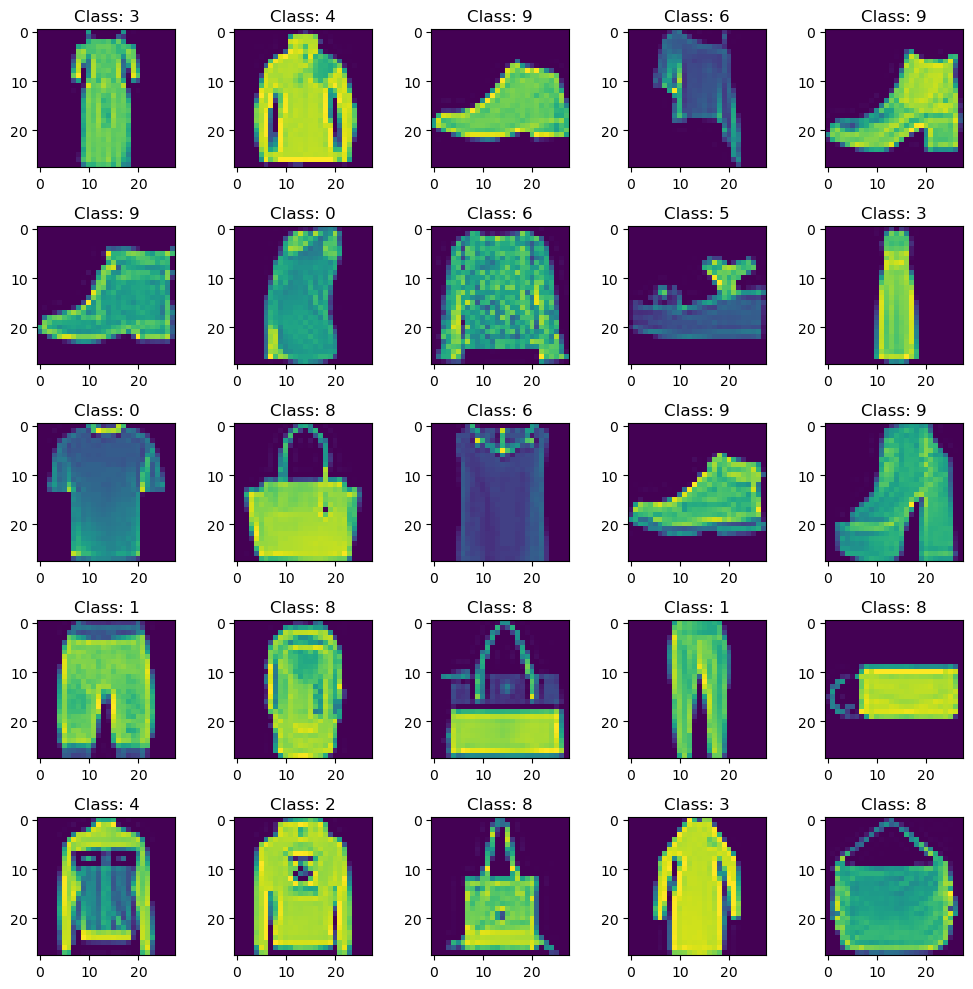

In [18]:
plt.figure(figsize=(10,10))
for idx in range(25):
    plt.subplot(5, 5, idx+1)
    plt.imshow(X_train[idx])
    plt.title('Class: {}'.format(y_train[idx]))
    
plt.tight_layout()

### Dodawanie dodatkowego wymiaru do macierzy

In [19]:
img_rows, img_cols = X_train.shape[1], X_train.shape[2]
X_train = X_train.reshape(-1, img_rows, img_cols, 1)
X_test = X_test.reshape(-1, img_rows, img_cols, 1)
X_valid = X_valid.reshape(-1, img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)
X_train.shape, X_test.shape, X_valid.shape

((48000, 28, 28, 1), (10000, 28, 28, 1), (12000, 28, 28, 1))

Kolejnym krokiem jest normalizacja danych. Jest to podzielenie każdej wartości w macierzy przez 255 (najwyższej możliwej wartości), aby wszystkie liczby były w przedziale [0-1].

### Normalizacja macierzy obrazów

In [20]:
if np.max(X_train) > 1 : X_train = (X_train / 255)
if np.max(X_test) > 1 : X_test = (X_test / 255)
if np.max(X_valid) > 1 : X_valid = (X_valid / 255)
X_valid.max()

1.0

Ostatnim krokiem obróbki danych jest zmiana etykiet liczbowych na wektory o rozmiarze równej ilości klas (ang. one-hot-encoding).
Wracając do przykładu kota i psa, jeśli kot oznacza klasę 0, a pies 1, każda z tych etykiet będzie zamieniona na wektor. Będzie on miał na jej miejscu porządkowym 1, a wszędzie indziej 0, czyli będzie równy [1,0] dla kota i [0,1] dla psa. Dla przykładu z 10 klasami, jeśli obraz jest zaklasyfikowany jako sukienka (numer 3), to etykieta zostanie zamieniona na wektor [0,0,0,1,0,0,0,0,0,0]. Biblioteka Keras posiada metodę to_categorical, która będzie tutaj pomocna.

### Zmiana etykiet liczbowych na węzły

In [21]:
if len(y_train.shape) == 1:
    num_classes = len(set(y_train))
    y_train = to_categorical(y_train, num_classes)
    y_test = to_categorical(y_test, num_classes)
    y_valid = to_categorical(y_valid, num_classes)
y_train.shape

(48000, 10)

Kiedy dane są gotowe, można zacząć tworzyć model. Aby stworzyć w miarę dokładny model, wystarczy kilka warstw. Im więcej warstw i transformacji, tym czas uczenia będzie dłuższy, a dokładność wcale nie musi być wyższa. Sieci o wysokiej skuteczności mają nawet kilkanaście warstw, ale ich uczenie to wielogodzinny proces. Można więc zacząć od dwóch warstw z filtrami i dwóch warstw łączenia.
W poniższym przykładzie mamy kolejno 32 i 64 filtry o rozmiarze 3x3 piksele, które równolegle skanują każdy obraz. MaxPool2D to warstwa łączenia, która spośród macierzy 2x2 przesuwanej po obrazie bierze najwyższą liczbę. Zmniejsza to sukcesywnie obraz i ułatwia jego przetwarzanie. Funkcja aktywacji ReLU zamienia wszystkie negatywne wartości w zera, co pozwala na szybsze uczenie. Wreszcie softmax odpowiada za budowanie wspomnianych wcześniej węzłów z wartościami prawdopodobieństw.

### Definicja modelu

In [27]:
model = Sequential([
  Conv2D(filters=32, kernel_size=(3, 3), input_shape=input_shape),
  MaxPool2D(pool_size=(2, 2)),
  Conv2D(filters=64, kernel_size=(3, 3)),
  MaxPool2D(pool_size=(2, 2)),
  Flatten(),
  Dense(512, activation='relu'),
  Dense(num_classes, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

In [28]:
from tensorflow.keras.utils import plot_model

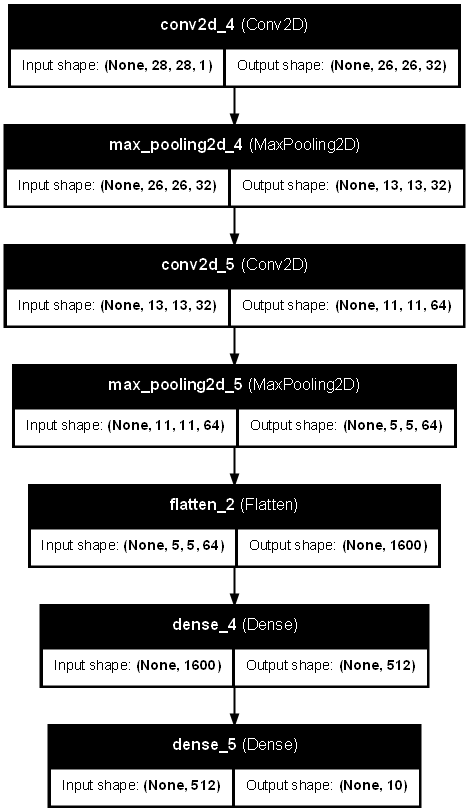

In [29]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model_architecture.png', dpi=72)

Oto skrócony opis architektury:

* InputLayer – obrazy 150×150×3 (RGB).
* Conv2D (32) – filtruje cechy, zmniejsza rozmiar do 148×148.
* MaxPooling2D – redukuje rozmiar do 74×74.
* Conv2D (64) – więcej filtrów, rozmiar 72×72.
* MaxPooling2D – redukcja do 36×36.
* Flatten – spłaszcza dane do 82944 cech.
* Dense (512) – warstwa w pełni połączona z aktywacją ReLU.
* Dense (num_classes) – klasyfikacja do klas wyjściowych z softmax.

Model najpierw wyodrębnia cechy z obrazu, a następnie klasyfikuje je.

#### TRENOWANIE I TESTOWANIE MODELU

Tak zdefiniowany model można nakarmić przygotowanymi danymi i rozpocząć naukę sieci. W tym przykładzie będzie 10 iteracji, po każdej z nich dokładność sieci powinna być wyższa.

Uczenie kończy się na poziomie ponad 91% dokładności dla zbioru walidacyjnego. To bardzo dobry wynik jak na tak prosty model.
Widać, że dokładność z prawie każdą iteracją rośnie, jest to dobry znak. Jeśli w pewnym momencie zaczęłaby spadać, oznaczałoby to przetrenowanie sieci. To nic innego jak zbyt dokładne dopasowanie do zbioru treningowego i coraz gorsza dokładność na obrazach ze zbioru walidacyjnego.

Czas na test na obrazach spoza zbioru! Jeśli posługujemy się zdjęciami z Internetu, należy je zmniejszyć do rozmiaru 28x28 pikseli, zamienić kolor na skalę odcieni szarości oraz znormalizować, podobnie jak obrazy z Fashion MNIST. Tak obrobionej macierzy obrazu należy użyć jako parametru funkcji predict wywołanej na modelu. Jak można się domyślić, przy wyborze zdjęcia bardzo podobnego do tych ze zbioru treningowego i walidacyjnego otrzymamy z dużym prawdopodobieństwem poprawne wyniki.

![brak obrazu](images/Rys4.png)

Rysunek 3. Przykładowa reprezentacja zbioru Fashion MNIST – każda kategoria jest prezentowana w 3 wierszach (źródło: https://github.com/zalandoresearch/fashion-mnist)

### Uczenie sieci

In [30]:
model.fit(
X_train, y_train,
batch_size=128,
epochs=10,
validation_data=(X_valid, y_valid)
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7430 - loss: 0.7170 - val_accuracy: 0.8678 - val_loss: 0.3687
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8727 - loss: 0.3530 - val_accuracy: 0.8853 - val_loss: 0.3099
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8921 - loss: 0.2904 - val_accuracy: 0.8929 - val_loss: 0.2895
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9113 - loss: 0.2409 - val_accuracy: 0.9038 - val_loss: 0.2592
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9233 - loss: 0.2093 - val_accuracy: 0.9006 - val_loss: 0.2692
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9342 - loss: 0.1766 - val_accuracy: 0.9089 - val_loss: 0.2526
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9438 - loss: 0.1515 - val_accuracy: 0.9062 - val_loss: 0.2671
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9546 - loss: 0.1280 - 

Jeśli jednak zdjęcia nie będą już tak oczywiste dla „oka” sieci, może być różnie. Jak widać na powyższym przykładzie, obrazy chociaż lekko odbiegające od tych ze zbioru uczącego mogą zostać zinterpretowane błędnie.

In [12]:
score = model.evaluate(X_test, y_test, verbose=0)
score

[0.3022012412548065, 0.906000018119812]

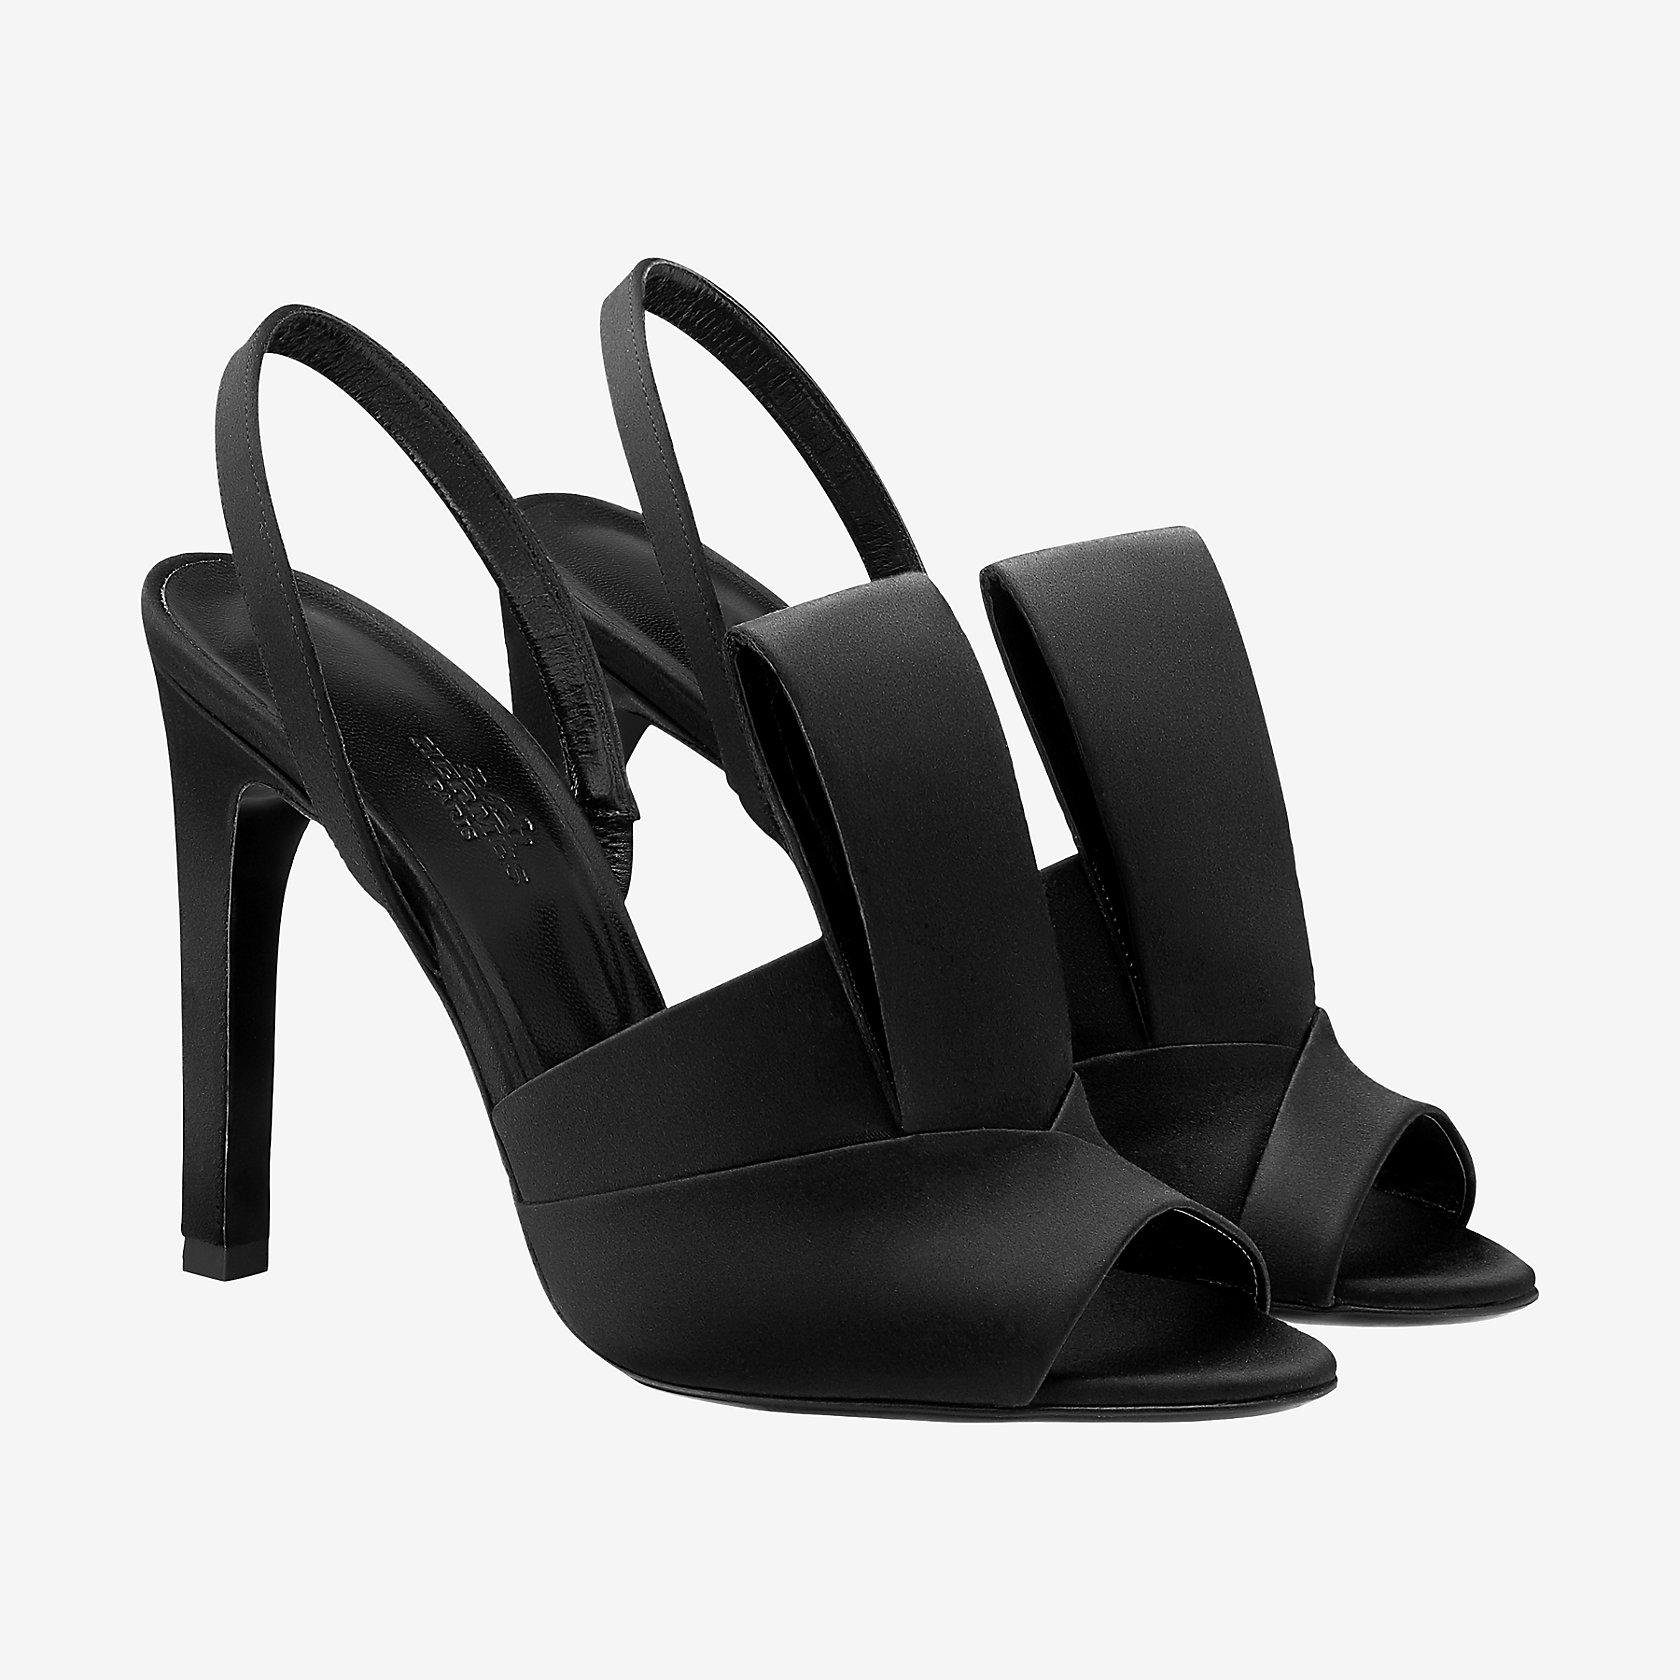

In [20]:
url_img = 'https://assets.hermes.com/is/image/hermesproduct/select-sandal--182033Z%2002-front-1-300-0-1680-1680.jpg'
response = requests.get(url_img)
img = Image.open(BytesIO(response.content)).convert('L')
img

In [31]:
PATH = ".\\images\\"
# img = Image.open(PATH + "buty.png")
img = Image.open(PATH + "spodnie.jpg").convert('L')

In [32]:
img = img.resize((28,28))
img

In [33]:
X = image.img_to_array(img)
X = np.expand_dims(X, axis=0)
X = X / 255
X.max()

1.0

In [34]:
y_pred = model.predict(X)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


array([[4.1833754e-08, 7.1305472e-01, 2.9234463e-13, 3.6968410e-15,
        1.7887227e-07, 4.1122244e-11, 2.5114075e-12, 1.7437806e-12,
        2.8694507e-01, 2.5341518e-13]], dtype=float32)

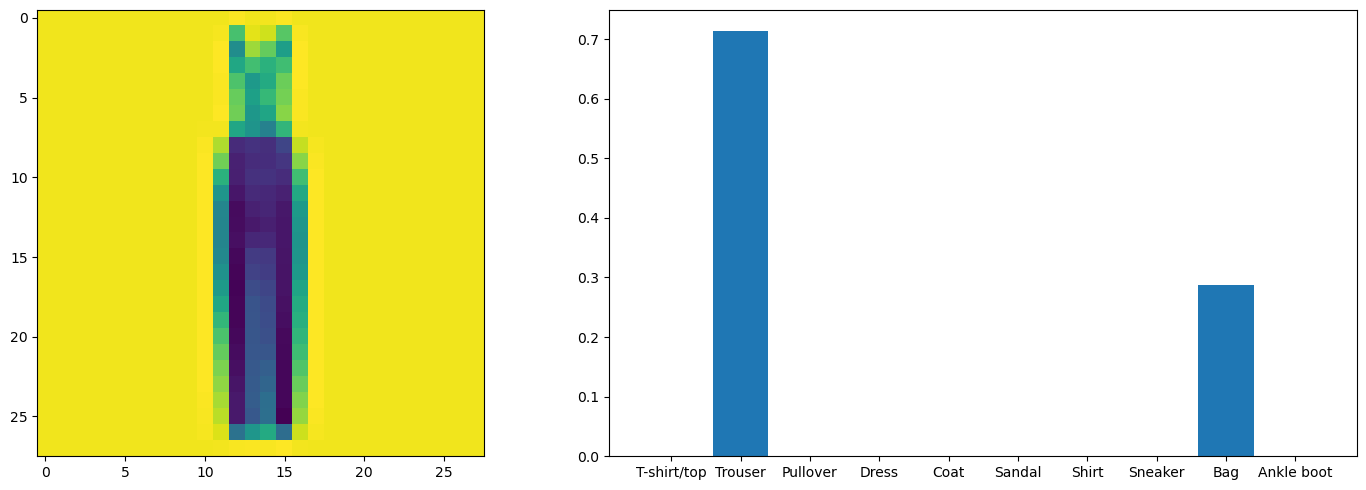

In [35]:
x = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
ax1.imshow(img)

ax2.bar(x, y_pred[0])
ax2.set_xticks(ticks=x)

plt.tight_layout()
plt.show()

## PODSUMOWANIE

Budowanie prostych sieci konwolucyjnych nie jest skomplikowanym procesem. Wystarczy użyć odpowiednich narzędzi. W przykładach posługiwałam się Pythonem i jego bibliotekami, ale tak naprawdę można to zrobić w każdej technologii. Eksperymentując z ilością i rodzajem warstw oraz różnymi filtrami, można zobaczyć, co służy szybkiemu i efektywnemu przetwarzaniu obrazów, a co powoduje przetrenowanie sieci i długi czas uczenia. Ważne też, aby dobrać zestaw danych, który jest interesujący. Wtedy praca z uczeniem maszynowym
i eksperymentowanie z rozpoznawaniem obrazów staje się przyjemną zabawą.

## Bibliogrfia 

Zbiór Fashion MNIST wraz z przykładami użycia w różnych językach:
»» https://github.com/zalandoresearch/fashion-mnist

Na podstawie artykułu: ALEKSANDRA KUNYSZ, Jak działa rozpoznawanie obrazu?, Programista 6/2019

https://colab.research.google.com/drive/1JFRsTJD72Ag3KpAfFOxUYp1nb71NIHPg